# Preprocessing Data: Dataset Pinjaman LendingClub (Accepted Loans)

**Nama:** Muhammad Zakiyyuddin Abdul Adhiim

**NIM:** 24/545668/TK/60719

**Prodi:** Teknologi Informasi 

**Dataset:** All Lending Club Loan Data, pinjaman yang disetujui (*accepted loans*), periode 2007&ndash;2018Q4

**Sumber:** https://www.kaggle.com/datasets/wordsforthewise/lending-club (berkas `accepted_2007_to_2018Q4.csv.gz`)

## Tentang dataset ini

LendingClub adalah perusahaan *peer-to-peer lending* (pinjaman antar-individu via platform online)
yang sudah menutup layanan retail-nya. Sebelum tutup, mereka mempublikasikan seluruh riwayat data
pinjaman yang pernah mereka proses apa adanya, tanpa dibersihkan terlebih dahulu. Ini menjadikan
dataset ini benar-benar representatif dari data operasional dunia nyata: penuh nilai hilang, tipe data
campuran, dan outlier yang sah secara bisnis, bukan dataset tutorial yang sudah dikurasi rapi.

Ukuran dataset asli: **2.260.701 baris &times; 151 kolom**. Karena ukuran ini terlalu besar untuk
diproses berulang kali secara interaktif dalam notebook, seluruh analisis di bawah dikerjakan pada
**sampel acak yang reproducible sebesar &plusmn;60.000 baris** (&asymp;2,65% dari data penuh). Sampel
diambil dengan cara membaca file asli per-*chunk* 100.000 baris lalu mengambil sampel acak proporsional
dari tiap chunk (`random_state=42`), sehingga sebaran waktu (2007&ndash;2018) dan proporsi antar
kategori pinjaman tetap terjaga seperti data aslinya. Seluruh 151 kolom asli dipertahankan tanpa
pembersihan apa pun sebelum sampling. jadi semua pola nilai hilang, tipe data, dan outlier yang
kita temukan di bawah benar-benar berasal dari data mentah, bukan hasil rekayasa.

## Struktur notebook ini

1. **Data Loading**: memuat sampel data mentah dan melihat sekilas isinya.
2. **Audit Kualitas Data (Sebelum Preprocessing)**: mengukur seberapa kotor data ini secara
   kuantitatif: tipe kolom, persentase nilai hilang, duplikat, dan outlier.
3. **Data Cleaning**: membuang kolom yang tidak berguna, memperbaiki tipe data, menangani nilai
   hilang, dan mengatasi outlier.
4. **Data Integration**: mendeteksi atribut yang redundan (tumpang tindih) lewat analisis
   korelasi, lalu membuangnya.
5. **Data Reduction (PCA)**: memampatkan dimensi data numerik dengan Principal Component
   Analysis.
6. **Perbandingan Sebelum vs. Sesudah**: merangkum dampak seluruh pipeline preprocessing secara
   kuantitatif dan visual.
7. **Insight Utama & Kesimpulan**: rangkuman temuan penting dari seluruh proses.


In [1]:
# Import seluruh library yang dibutuhkan 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 60)

# Lokasi file data mentah (hasil sampling) dan folder output
RAW_PATH = '../data/raw/lendingclub_sample_raw.csv'
FIG_DIR = '../figures'
PROCESSED_DIR = '../data/processed'
import os
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)


## 1. Pengambilan Sampel dari Dataset Asli (2.260.701 baris)

Dataset penuh (`accepted_2007_to_2018Q4.csv.gz`, berkas *accepted loans* dari LendingClub) memiliki
**2.260.701 baris &times; 151 kolom** (&asymp;392 MB terkompresi, &asymp;1,6 GB setelah diekstrak).
Ukuran ini terlalu besar untuk diproses berulang kali secara interaktif di notebook, sehingga kita
bekerja pada sampel acak sebesar 60.000 baris. Sel-sel di bawah ini menunjukkan bagaimana
sampel tersebut diambil dari data penuh, agar prosesnya transparan dan dapat direproduksi ulang oleh
siapa pun.

**Langkah 1. Unduh data penuh (jika belum ada):** berkas mentah penuh diunduh dari Kaggle
(https://www.kaggle.com/datasets/wordsforthewise/lending-club) memakai Kaggle API. Ini membutuhkan
kredensial API Kaggle (`~/.kaggle/kaggle.json`) yang sudah dikonfigurasi di komputer yang menjalankan
notebook ini. Jika berkas sudah pernah diunduh sebelumnya, langkah ini dilewati.

**Langkah 2. Sampling per-chunk:** karena file berukuran &asymp;1,6 GB, kita tidak memuat
seluruh isinya ke memori sekaligus. Sebagai gantinya, file dibaca bertahap (*chunk*) sebesar 100.000
baris. Dari setiap chunk, diambil sampel acak secara proporsional (bukan hanya mengambil 60.000
baris pertama), karena data ini terurut berdasarkan tanggal penerbitan pinjaman (`issue_d`) mengambil hanya baris-baris awal akan menghasilkan sampel yang bias, hanya berisi pinjaman dari
periode-periode awal saja. `random_state=42` dipakai konsisten di seluruh chunk agar hasil sampling
ini **reproducible**, artinya siapa pun yang menjalankan ulang kode ini akan mendapatkan 60.000 baris yang
persis sama.

Hasil sampel disimpan ke `data/raw/lendingclub_sample_raw.csv`, yang kemudian dipakai oleh seluruh
sel pada Bagian 2 dan seterusnya.

In [2]:
import os

RAW_FULL_PATH = '../data/raw/accepted_2007_to_2018Q4.csv.gz'

# Unduh berkas mentah penuh dari Kaggle hanya jika belum tersedia secara lokal
if not os.path.exists(RAW_FULL_PATH):
    print('Berkas data mentah penuh belum ada, mengunduh dari Kaggle...')
    !kaggle datasets download -f accepted_2007_to_2018Q4.csv.gz wordsforthewise/lending-club -p ../data/raw --force
else:
    print('Berkas data mentah penuh sudah tersedia, lanjut ke tahap sampling.')


Berkas data mentah penuh sudah tersedia, lanjut ke tahap sampling.


In [3]:
import gzip

SAMPLE_SIZE = 60_000
RANDOM_SEED = 42

# Hitung jumlah baris data pada file mentah penuh (tidak termasuk baris header)
with gzip.open(RAW_FULL_PATH, 'rt') as f:
    total_rows = sum(1 for _ in f) - 1
print(f'Total baris pada dataset asli (accepted loans): {total_rows:,}')

frac = SAMPLE_SIZE / total_rows
print(f'Fraksi sampling yang digunakan: {frac:.4f} (~{frac * 100:.2f}% dari data penuh)')

# Sampling dilakukan per-chunk 100.000 baris (bukan memuat ~1,6 GB sekaligus ke memori).
# Sampel diambil dari SETIAP chunk secara proporsional, bukan hanya baris-baris awal,
# supaya seluruh rentang waktu 2007-2018 tetap terwakili sesuai proporsi aslinya.
chunks = []
reader = pd.read_csv(RAW_FULL_PATH, compression='gzip', chunksize=100_000, low_memory=False)
for chunk in reader:
    chunks.append(chunk.sample(frac=frac, random_state=RANDOM_SEED))

df_sample = pd.concat(chunks, ignore_index=True)
print('Ukuran sampel akhir:', df_sample.shape)

df_sample.to_csv(RAW_PATH, index=False)
print(f'Sampel data mentah berhasil disimpan ke {RAW_PATH}')


Total baris pada dataset asli (accepted loans): 2,260,701
Fraksi sampling yang digunakan: 0.0265 (~2.65% dari data penuh)


Ukuran sampel akhir: (59999, 151)


Sampel data mentah berhasil disimpan ke ../data/raw/lendingclub_sample_raw.csv


## 2. Data Loading

Sel di bawah memuat sampel data mentah (hasil sampling ~60.000 baris dari 2,26 juta baris data asli,
lihat penjelasan di atas) ke dalam sebuah DataFrame pandas. Kita tampilkan jumlah baris/kolom serta
lima baris pertama untuk memastikan data terbaca dengan benar sebelum masuk ke tahap audit.

In [4]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print('Ukuran sampel data mentah:', df_raw.shape)
df_raw.head()


Ukuran sampel data mentah: (59999, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,63957998,NaN,14400.0,14400.0,14400.0,60 months,16.55,354.41,D,D2,CPL,3 years,OWN,45204.0,Source Verified,Nov-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,799xx,TX,27.42,0.0,Aug-2012,680.0,684.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,61943206,NaN,30000.0,30000.0,29900.0,60 months,12.69,677.85,C,C2,Engineering Manager,2 years,MORTGAGE,131000.0,Source Verified,Nov-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,credit_card,Credit card refinancing,301xx,GA,33.80,0.0,Apr-1998,685.0,689.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,67275890,NaN,6000.0,6000.0,5850.0,36 months,15.41,209.20,D,D1,Loan officer,1 year,MORTGAGE,35000.0,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,292xx,SC,35.67,1.0,Jul-2006,665.0,669.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,63917579,NaN,22000.0,22000.0,22000.0,36 months,13.67,748.39,C,C4,General Manager,3 years,MORTGAGE,133000.0,Verified,Nov-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,Home improvement,385xx,TN,15.82,0.0,Feb-1999,735.0,739.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,63184618,NaN,35000.0,35000.0,35000.0,60 months,13.33,802.29,C,C3,lieutenant,10+ years,MORTGAGE,120000.0,Source Verified,Oct-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,Home improvement,103xx,NY,8.28,2.0,Feb-1990,730.0,734.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Audit Kualitas Data Awal (Sebelum Preprocessing)

Sebelum melakukan perubahan apa pun terhadap data, kita perlu mengukur secara kuantitatif seberapa
"kotor" data mentah ini. Bagian ini menjawab empat pertanyaan dasar:

- **Tipe data apa saja yang ada?** numerik vs. string/objek
- **Kolom mana yang paling banyak kehilangan nilai?** ini menentukan strategi cleaning di
  Bagian 3.
- **Apakah ada baris duplikat?** baik duplikat ID pinjaman maupun duplikat baris penuh
- **Seberapa ekstrem outlier pada kolom finansial kunci?** sebelum ditangani di Bagian 3.4.

Angka-angka pada bagian ini nantinya akan dibandingkan langsung dengan kondisi data setelah
preprocessing pada Bagian 6, sebagai bukti kuantitatif dampak dari setiap langkah yang kita lakukan.

In [5]:
# Hitung distribusi tipe data kolom
dtype_counts = df_raw.dtypes.value_counts()
print('Distribusi tipe data kolom:\n', dtype_counts)

# Hitung persentase nilai hilang per kolom, diurutkan dari yang terbesar
missing_pct = df_raw.isna().mean().sort_values(ascending=False) * 100
n_fully_empty = (missing_pct == 100).sum()
n_over_95 = (missing_pct > 95).sum()
n_zero_missing = (missing_pct == 0).sum()
print(f'\nJumlah kolom yang 100% kosong: {n_fully_empty}')
print(f'Jumlah kolom dengan >95% nilai hilang: {n_over_95}')
print(f'Jumlah kolom tanpa nilai hilang sama sekali: {n_zero_missing}')
missing_pct.head(20)


Distribusi tipe data kolom:
 float64    113
str         38
Name: count, dtype: int64

Jumlah kolom yang 100% kosong: 1
Jumlah kolom dengan >95% nilai hilang: 35
Jumlah kolom tanpa nilai hilang sama sekali: 1


member_id                                     100.000000
orig_projected_additional_accrued_interest     99.616660
hardship_reason                                99.514992
hardship_payoff_balance_amount                 99.514992
hardship_last_payment_amount                   99.514992
payment_plan_start_date                        99.514992
hardship_type                                  99.514992
hardship_status                                99.514992
hardship_start_date                            99.514992
deferral_term                                  99.514992
hardship_amount                                99.514992
hardship_dpd                                   99.514992
hardship_loan_status                           99.514992
hardship_length                                99.514992
hardship_end_date                              99.514992
sec_app_mths_since_last_major_derog            98.474975
settlement_status                              98.454974
debt_settlement_flag_date      

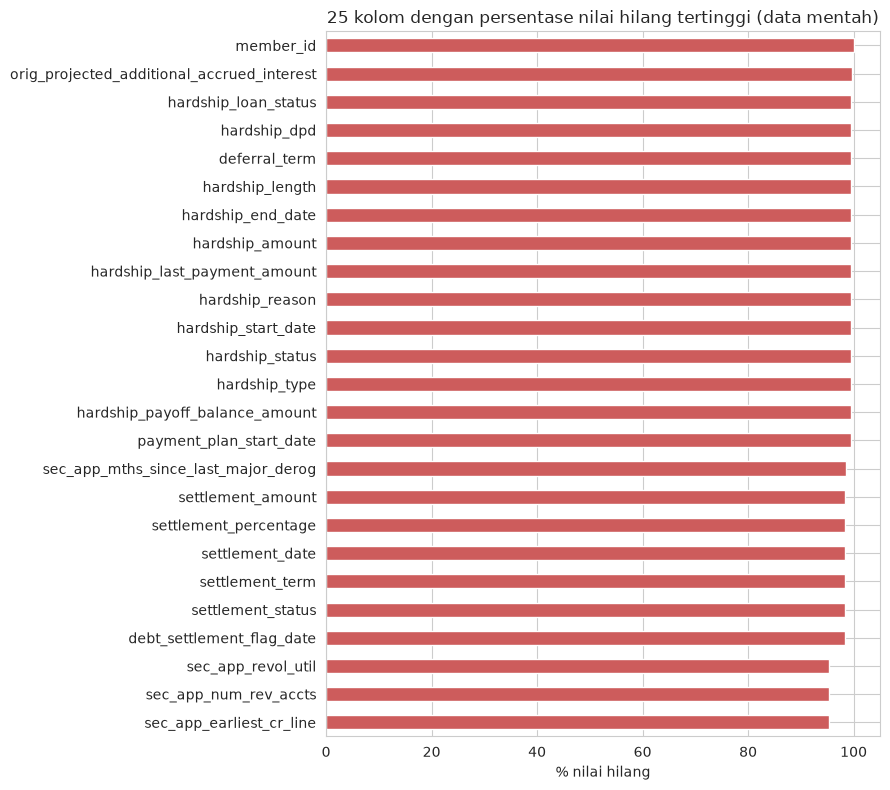

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
missing_pct.head(25).sort_values().plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('% nilai hilang')
ax.set_title('25 kolom dengan persentase nilai hilang tertinggi (data mentah)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_missing_before.png')
plt.show()


In [7]:
# Cek duplikat: baik pada level ID pinjaman maupun baris penuh
dup_ids = df_raw['id'].duplicated().sum()
dup_rows = df_raw.duplicated().sum()
print(f'Jumlah ID pinjaman duplikat: {dup_ids}')
print(f'Jumlah baris yang sepenuhnya duplikat: {dup_rows}')


Jumlah ID pinjaman duplikat: 0
Jumlah baris yang sepenuhnya duplikat: 0


In [8]:
print("Contoh kolom yang seharusnya numerik tapi tersimpan sebagai string:")
print(df_raw[['term', 'issue_d', 'earliest_cr_line', 'emp_length']].sample(5, random_state=1))

print('\nRingkasan statistik annual_inc (perhatikan nilai maksimum vs. median yang jauh berbeda):')
print(df_raw['annual_inc'].describe())


Contoh kolom yang seharusnya numerik tapi tersimpan sebagai string:
             term   issue_d earliest_cr_line emp_length
6419    60 months  May-2015         Jul-2006   < 1 year
19262   36 months  Apr-2016         Aug-1998        NaN
50776   36 months  Aug-2012         Aug-1987    3 years
12637   36 months  Feb-2018         Oct-2011    6 years
13397   60 months  Sep-2017         Dec-2006  10+ years

Ringkasan statistik annual_inc (perhatikan nilai maksimum vs. median yang jauh berbeda):
count    5.999800e+04
mean     7.784120e+04
std      5.682267e+04
min      0.000000e+00
25%      4.680000e+04
50%      6.500000e+04
75%      9.400000e+04
max      3.000000e+06
Name: annual_inc, dtype: float64


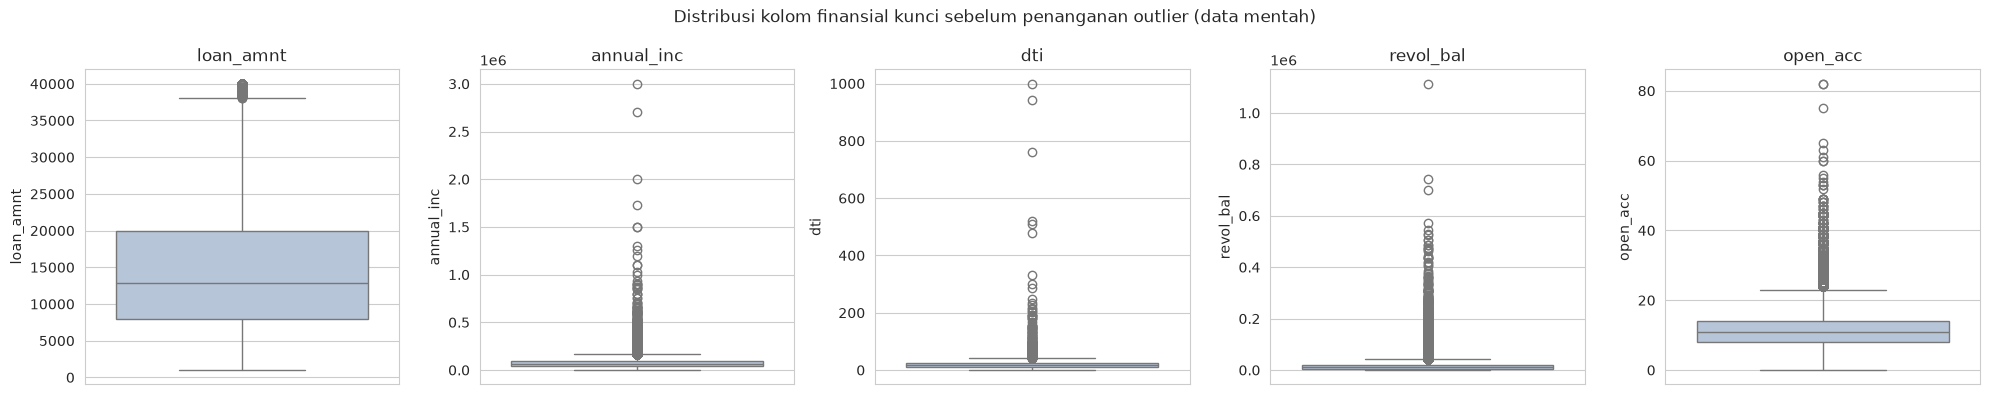

In [9]:
# Visualisasi sebaran kolom finansial kunci sebelum penanganan outlier
key_cols = ['loan_amnt', 'annual_inc', 'dti', 'revol_bal', 'open_acc']
fig, axes = plt.subplots(1, len(key_cols), figsize=(20, 4))
for ax, col in zip(axes, key_cols):
    sns.boxplot(y=df_raw[col].dropna(), ax=ax, color='lightsteelblue')
    ax.set_title(col)
plt.suptitle('Distribusi kolom finansial kunci sebelum penanganan outlier (data mentah)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_outliers_before.png')
plt.show()


## 4. Data Cleaning

Berdasarkan temuan audit di Bagian 2, kita melakukan empat langkah cleaning secara berurutan:

1. **Membuang kolom yang hampir sepenuhnya kosong** (struktural, bukan acak).
2. **Memperbaiki tipe data** yang salah tersimpan sebagai string.
3. **Menangani nilai hilang** yang tersisa pada kolom dengan missingness moderat.
4. **Mendeteksi & menangani outlier** pada kolom finansial kunci.

### 3.1 Membuang kolom yang hampir kosong secara struktural

Kolom-kolom dengan >95% nilai hilang (field program *hardship*, *debt settlement*, dan
aplikasi bersama/*joint applicant*, ditambah `member_id` yang 100% kosong karena anonimisasi) **tidak
kita imputasi**, karena kekosongannya bukan disebabkan oleh kesalahan input data, melainkan karena
field tersebut memang hanya relevan untuk subset kecil pinjaman tertentu (mis. hanya pinjaman yang
sedang mengikuti program hardship yang punya nilai di kolom `hardship_*`). Mengimputasi kolom seperti
ini hanya akan menciptakan informasi palsu, sehingga solusi yang lebih tepat adalah membuangnya.

In [10]:
drop_cols = missing_pct[missing_pct > 95].index.tolist()
print(f'Membuang {len(drop_cols)} kolom dengan >95% nilai hilang:')
print(drop_cols)

df = df_raw.drop(columns=drop_cols)
print('\nUkuran data setelah membuang kolom yang hampir kosong:', df.shape)


Membuang 35 kolom dengan >95% nilai hilang:
['member_id', 'orig_projected_additional_accrued_interest', 'hardship_reason', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'payment_plan_start_date', 'hardship_type', 'hardship_status', 'hardship_start_date', 'deferral_term', 'hardship_amount', 'hardship_dpd', 'hardship_loan_status', 'hardship_length', 'hardship_end_date', 'sec_app_mths_since_last_major_derog', 'settlement_status', 'debt_settlement_flag_date', 'settlement_date', 'settlement_percentage', 'settlement_amount', 'settlement_term', 'sec_app_revol_util', 'sec_app_num_rev_accts', 'sec_app_earliest_cr_line', 'sec_app_mort_acc', 'sec_app_open_acc', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_open_act_il', 'sec_app_inq_last_6mths', 'sec_app_fico_range_high', 'sec_app_collections_12_mths_ex_med', 'sec_app_chargeoff_within_12_mths', 'verification_status_joint']

Ukuran data setelah membuang kolom yang hampir kosong: (59999, 116)


### 4.2 Memperbaiki tipe data

Beberapa kolom yang secara semantik adalah angka justru tersimpan sebagai teks bebas, sehingga tidak
bisa langsung dipakai untuk perhitungan statistik maupun model. Kita perbaiki tiga di antaranya:

- `term` tersimpan sebagai `" 36 months"` &rarr; diekstrak angkanya menjadi `36` (float).
- Kolom tanggal (`issue_d`, `earliest_cr_line`, `last_pymnt_d`, `last_credit_pull_d`) tersimpan
  sebagai string `"Apr-2018"` &rarr; diparsing menjadi tipe `datetime`.
- `emp_length` tersimpan sebagai `"< 1 year"`, `"10+ years"`, dll. &rarr; dikonversi menjadi
  jumlah tahun numerik.

In [11]:
# term: ' 36 months' -> 36 (angka)
df['term'] = df['term'].str.extract(r'(\d+)').astype(float)

# issue_d / earliest_cr_line / last_pymnt_d / last_credit_pull_d: 'Apr-2018' -> datetime
date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], format='%b-%Y', errors='coerce')

# emp_length: 'n/a', '< 1 year', '10+ years' -> angka tahun
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if '<' in x:
        return 0
    return float(''.join(ch for ch in x if ch.isdigit()))

df['emp_length'] = df['emp_length'].apply(parse_emp_length)

print('Tipe data setelah diperbaiki:')
print(df[['term', 'issue_d', 'earliest_cr_line', 'emp_length']].dtypes)
df[['term', 'issue_d', 'earliest_cr_line', 'emp_length']].sample(5, random_state=1)


Tipe data setelah diperbaiki:
term                       float64
issue_d             datetime64[us]
earliest_cr_line    datetime64[us]
emp_length                 float64
dtype: object


,term,issue_d,earliest_cr_line,emp_length
6419,60.0,2015-05-01,2006-07-01,0.0
19262,36.0,2016-04-01,1998-08-01,NaN
50776,36.0,2012-08-01,1987-08-01,3.0
12637,36.0,2018-02-01,2011-10-01,6.0
13397,60.0,2017-09-01,2006-12-01,10.0


### 4.3 Menangani nilai hilang yang tersisa

Strategi yang dipakai:

- Kolom **numerik** yang masih memiliki nilai hilang diimputasi dengan **median** (lebih robust
  terhadap outlier dibanding mean, sehingga tidak bias oleh nilai ekstrem seperti `annual_inc` yang
  mencapai jutaan dolar).
- Kolom **kategorikal/teks** yang masih memiliki nilai hilang diisi dengan label `"Unknown"`, supaya
  informasi "nilai ini memang tidak diketahui" tetap eksplisit alih-alih dihapus begitu saja.
- Kolom **teks bebas berkardinalitas tinggi** (`emp_title`, `url`, `desc`, `title`, `zip_code`) dibuang
  karena tidak dapat diolah secara numerik dan tidak relevan untuk analisis korelasi maupun PCA pada
  notebook ini.

In [12]:
text_cols_to_drop = [c for c in ['emp_title', 'url', 'desc', 'title', 'zip_code'] if c in df.columns]
df = df.drop(columns=text_cols_to_drop)
print('Kolom teks bebas/berkardinalitas tinggi yang dibuang:', text_cols_to_drop)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'\nJumlah kolom numerik: {len(numeric_cols)} | Jumlah kolom kategorikal: {len(categorical_cols)}')

missing_before_impute = df.isna().mean().mean() * 100
print(f'Rata-rata persentase nilai hilang di seluruh kolom sebelum imputasi: {missing_before_impute:.2f}%')

for c in numeric_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())

for c in categorical_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna('Unknown')

missing_after_impute = df.isna().mean().mean() * 100
print(f'Rata-rata persentase nilai hilang setelah imputasi: {missing_after_impute:.2f}%')


Kolom teks bebas/berkardinalitas tinggi yang dibuang: ['emp_title', 'url', 'desc', 'title', 'zip_code']

Jumlah kolom numerik: 92 | Jumlah kolom kategorikal: 15


Rata-rata persentase nilai hilang di seluruh kolom sebelum imputasi: 11.52%


Rata-rata persentase nilai hilang setelah imputasi: 0.00%


/tmp/ipykernel_102169/2832514987.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


### 4.4 Deteksi & penanganan outlier

Kita gunakan aturan **IQR (Interquartile Range)** pada enam kolom finansial kunci untuk mendeteksi
outlier. Alih-alih menghapus baris yang mengandung outlier (yang akan mengurangi volume data dan
berpotensi membuang informasi penting), kita memilih untuk **meng-capping/winsorize** nilai tersebut, yaitu membatasi nilai ekstrem pada batas bawah/atas IQR, karena nilai ekstrem pada
pendapatan (`annual_inc`) atau rasio utang (`dti`) umumnya adalah nilai yang sah (memang ada orang
berpenghasilan sangat tinggi), bukan kesalahan input data. Capping mengurangi pengaruh nilai ekstrem
tanpa kehilangan baris data.

In [13]:
def batas_iqr(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_cols = ['annual_inc', 'dti', 'revol_bal', 'loan_amnt', 'open_acc', 'total_acc']
outlier_report = {}
for c in outlier_cols:
    low, high = batas_iqr(df[c])
    n_out = ((df[c] < low) | (df[c] > high)).sum()
    outlier_report[c] = {'batas_bawah': low, 'batas_atas': high, 'jumlah_outlier': n_out,
                          'persen_outlier': 100 * n_out / len(df)}
    df[c] = df[c].clip(lower=low, upper=high)

pd.DataFrame(outlier_report).T


,batas_bawah,batas_atas,jumlah_outlier,persen_outlier
annual_inc,-24000.000,164800.000,2919.0,4.865081
dti,-7.095,43.345,522.0,0.870015
revol_bal,-15643.000,42037.000,3646.0,6.076768
loan_amnt,-10000.000,38000.000,948.0,1.580026
open_acc,-1.000,23.000,2279.0,3.798397
total_acc,-9.000,55.000,1021.0,1.701695


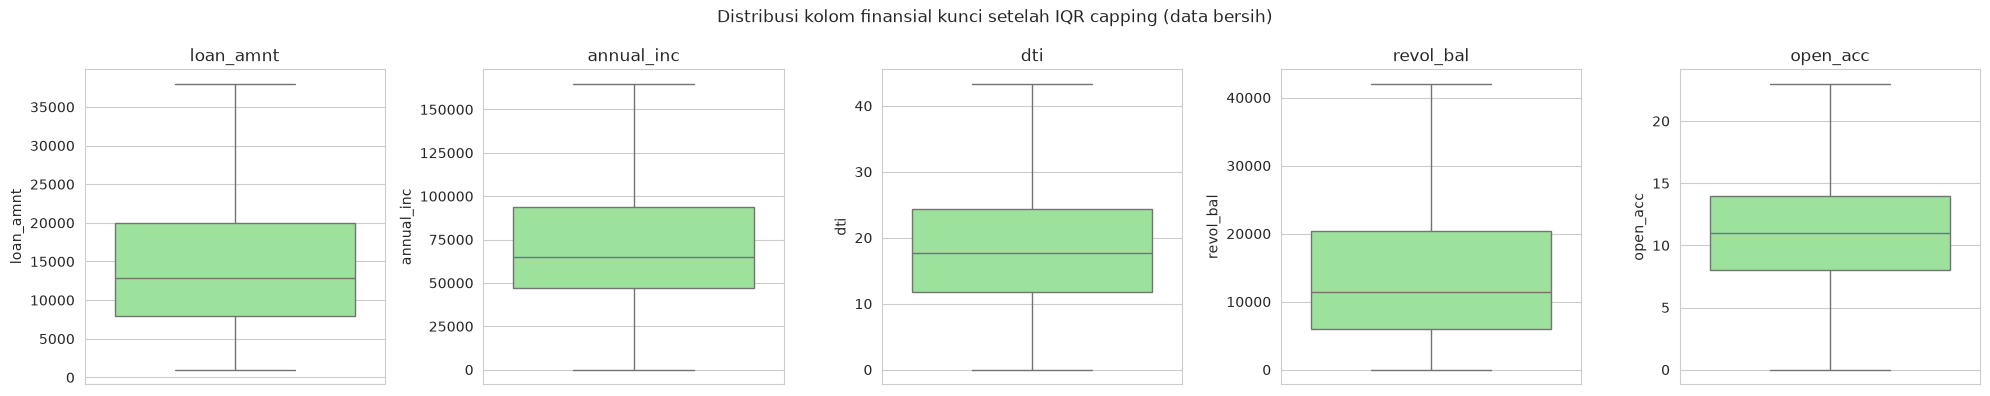

In [14]:
fig, axes = plt.subplots(1, len(key_cols), figsize=(20, 4))
for ax, col in zip(axes, key_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(col)
plt.suptitle('Distribusi kolom finansial kunci setelah IQR capping (data bersih)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_outliers_after.png')
plt.show()


In [15]:
dup_rows_after = df.duplicated().sum()
print(f'Jumlah baris duplikat setelah cleaning: {dup_rows_after}')
df = df.drop_duplicates()
print('Ukuran data setelah seluruh proses cleaning:', df.shape)


Jumlah baris duplikat setelah cleaning: 0
Ukuran data setelah seluruh proses cleaning: (59999, 111)


## 5. Data Integration: Deteksi Atribut Redundan

Skema data LendingClub memuat banyak kolom finansial turunan yang secara semantik tumpang tindih satu
sama lain, misalnya `funded_amnt` vs. `loan_amnt` (jumlah dana yang dicairkan hampir selalu
sama dengan jumlah yang diajukan), atau `total_pymnt` vs. `total_rec_prncp` + `total_rec_int` (total
pembayaran adalah hasil penjumlahan dari pokok dan bunga yang sudah diterima). Kolom-kolom semacam ini
tidak menambah informasi baru bagi analisis, tetapi justru menambah dimensi data secara tidak perlu.

Untuk mendeteksinya secara sistematis (bukan menebak-nebak), kita hitung **matriks korelasi Pearson**
antar seluruh kolom numerik, lalu tandai setiap pasangan kolom dengan **|r| > 0,9** sebagai kandidat
redundan. Dari setiap pasangan yang terdeteksi, salah satu kolomnya dibuang.

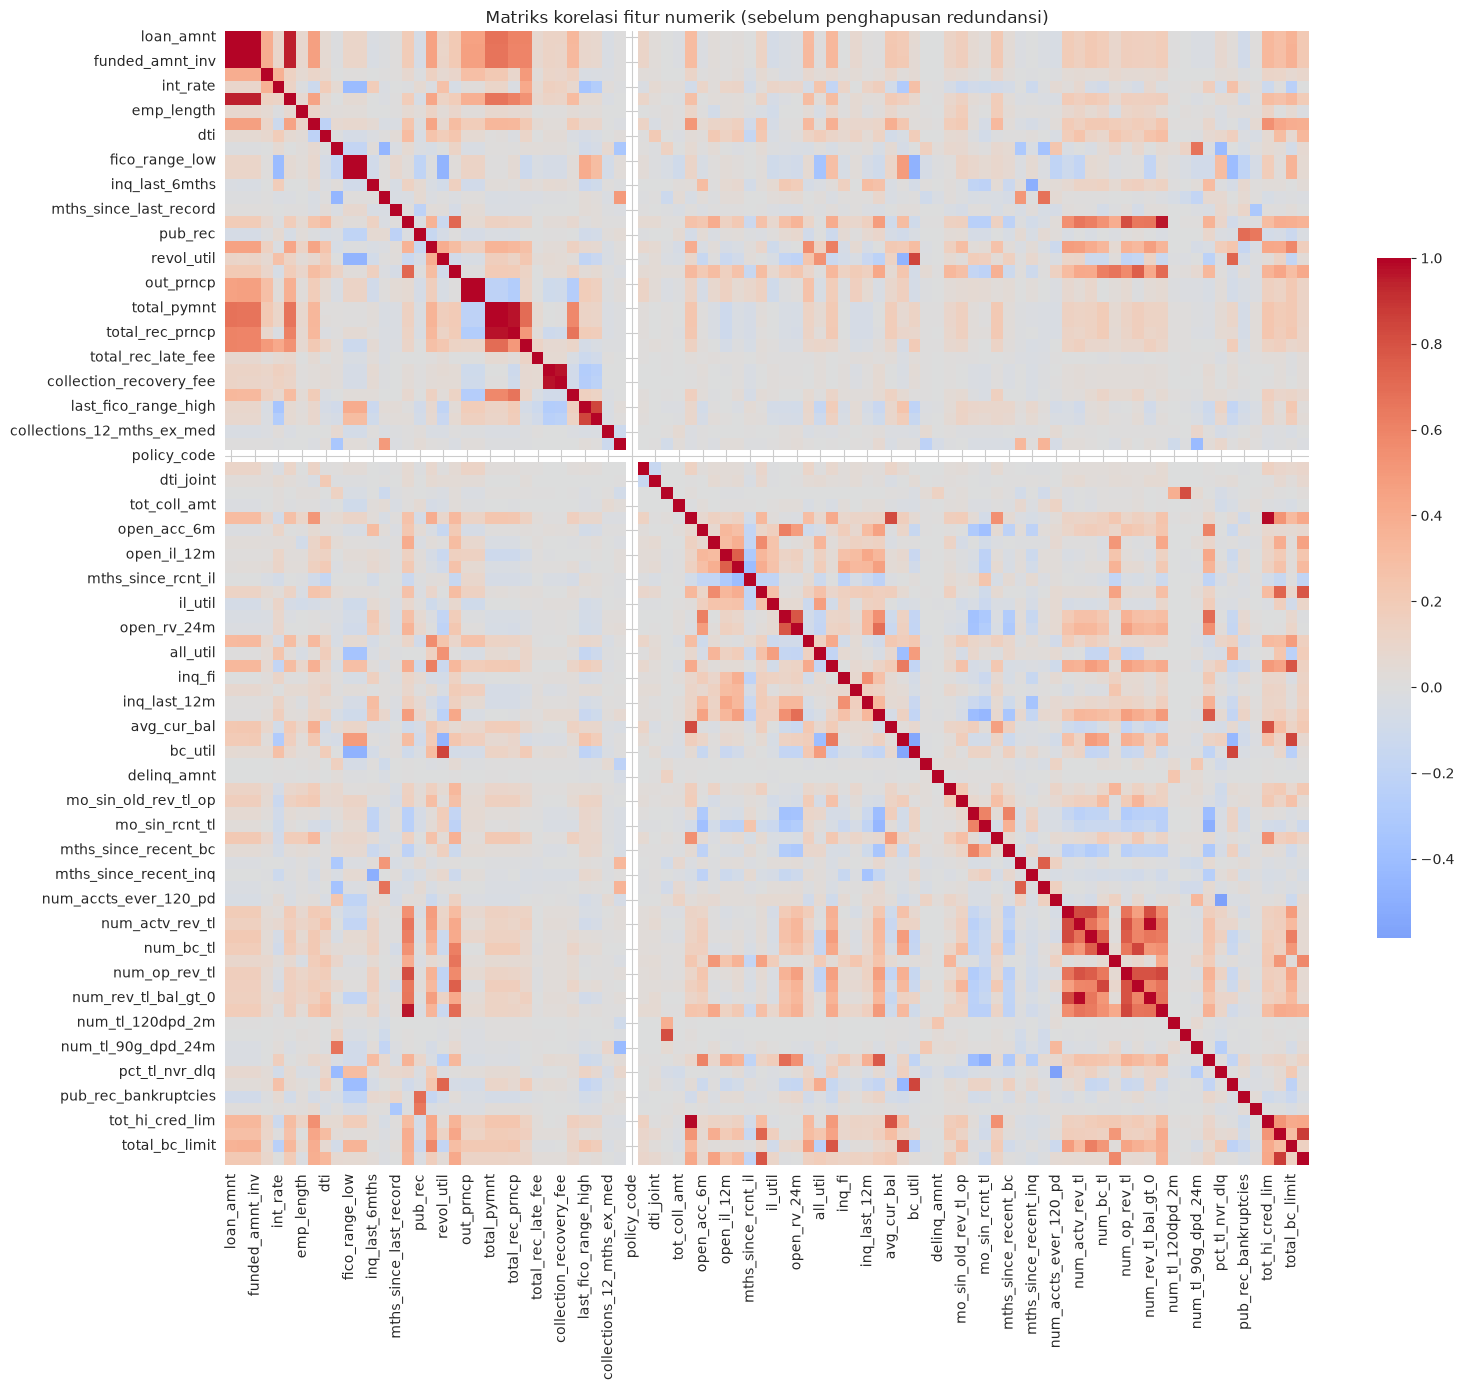

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Matriks korelasi fitur numerik (sebelum penghapusan redundansi)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_corr_before.png')
plt.show()


In [17]:
# Cari pasangan kolom dengan korelasi sangat tinggi (|r| > 0.9), simpan kolom pertama dari tiap pasangan
threshold = 0.9
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant_pairs = [(col, row, upper.loc[row, col])
                    for col in upper.columns for row in upper.index
                    if pd.notna(upper.loc[row, col]) and abs(upper.loc[row, col]) > threshold]
redundant_pairs = sorted(redundant_pairs, key=lambda x: -abs(x[2]))
print(f'Ditemukan {len(redundant_pairs)} pasangan kolom dengan |korelasi| > {threshold}:')
for a, b, v in redundant_pairs:
    print(f'  {a:35s} <-> {b:35s}  r = {v:.3f}')


Ditemukan 15 pasangan kolom dengan |korelasi| > 0.9:
  fico_range_high                     <-> fico_range_low                       r = 1.000
  out_prncp_inv                       <-> out_prncp                            r = 1.000
  funded_amnt                         <-> loan_amnt                            r = 0.999
  total_pymnt_inv                     <-> total_pymnt                          r = 0.999
  funded_amnt_inv                     <-> funded_amnt                          r = 0.999
  funded_amnt_inv                     <-> loan_amnt                            r = 0.999
  num_rev_tl_bal_gt_0                 <-> num_actv_rev_tl                      r = 0.984
  tot_hi_cred_lim                     <-> tot_cur_bal                          r = 0.984
  total_rec_prncp                     <-> total_pymnt                          r = 0.967
  total_rec_prncp                     <-> total_pymnt_inv                      r = 0.966
  collection_recovery_fee             <-> recoveries     

In [18]:
to_drop_redundant = sorted({b for _, b, _ in redundant_pairs})
print(f'Membuang {len(to_drop_redundant)} kolom redundan:')
print(to_drop_redundant)

df_integrated = df.drop(columns=to_drop_redundant)
print('\nUkuran data setelah penghapusan redundansi:', df_integrated.shape)


Membuang 11 kolom redundan:
['fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'loan_amnt', 'num_actv_rev_tl', 'open_acc', 'out_prncp', 'recoveries', 'tot_cur_bal', 'total_pymnt', 'total_pymnt_inv']

Ukuran data setelah penghapusan redundansi: (59999, 100)


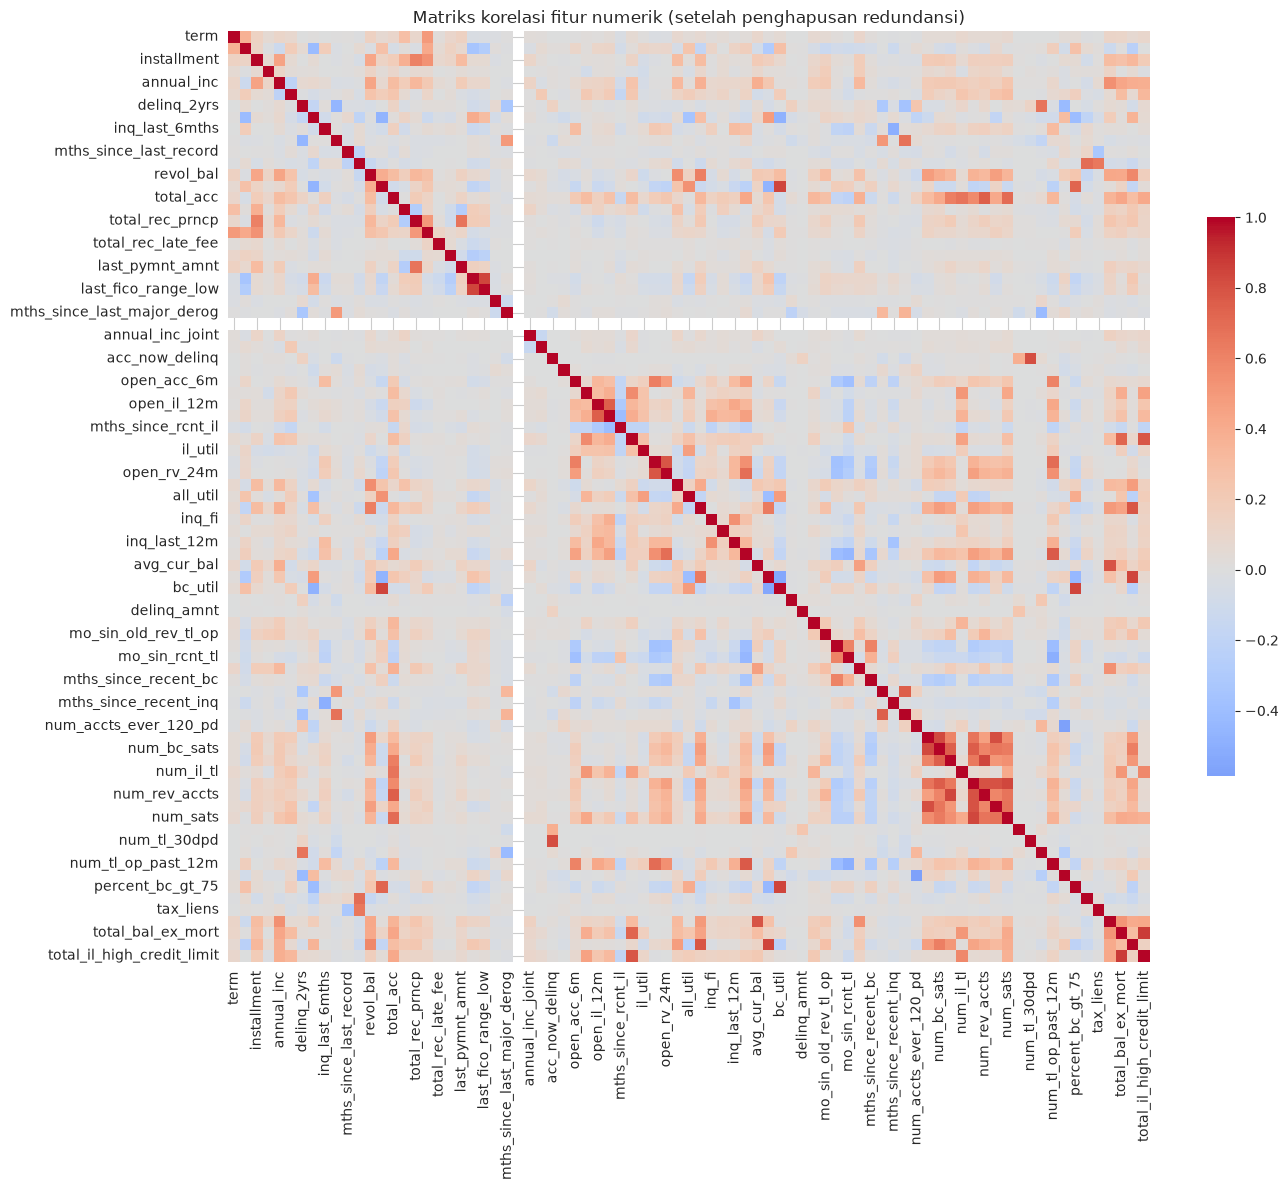

In [19]:
numeric_cols_after = df_integrated.select_dtypes(include=[np.number]).columns.tolist()
corr_after = df_integrated[numeric_cols_after].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_after, cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Matriks korelasi fitur numerik (setelah penghapusan redundansi)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_corr_after.png')
plt.show()


## 6. Data Reduction: Principal Component Analysis (PCA)

Setelah tahap integrasi, data masih memiliki puluhan kolom numerik yang saling berkorelasi
lemah-sedang (di bawah ambang 0,9 sehingga tidak terdeteksi sebagai "redundan" pada Bagian 4, namun
tetap mengandung informasi yang tumpang tindih sebagian). PCA dipakai untuk memampatkan dimensi data
ini menjadi lebih sedikit **komponen utama** (*principal components*) yang merupakan kombinasi linear
dari fitur asli, sambil mempertahankan sebagian besar variansi (informasi) data.

Langkah-langkahnya:
1. **Standarisasi** (z-score) seluruh fitur numerik, wajib dilakukan sebelum PCA, karena PCA
   sensitif terhadap skala; tanpa ini, kolom dengan rentang nilai besar (mis. `annual_inc` dalam
   satuan dolar) akan mendominasi hasil PCA dibanding kolom dengan rentang kecil (mis. `dti`).
2. **Fit PCA** pada seluruh komponen untuk melihat berapa banyak variansi yang dijelaskan tiap
   komponen (*scree plot*).
3. **Pilih jumlah komponen** yang mempertahankan &ge;90% total variansi.
4. **Transformasi** data ke ruang komponen utama tersebut.

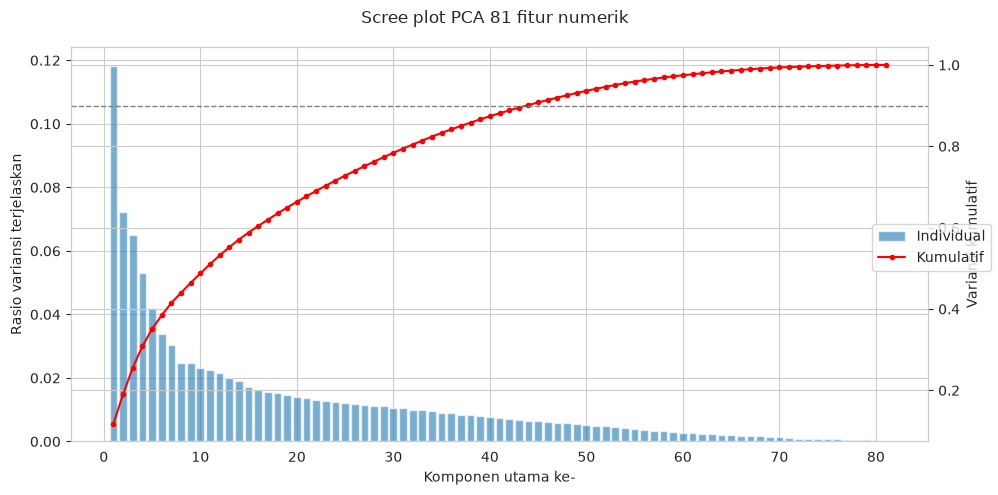

Jumlah fitur numerik asal: 81
Jumlah komponen yang dibutuhkan untuk mempertahankan >=90% variansi: 44


In [20]:
feature_cols = df_integrated.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ['id']]
X = df_integrated[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, len(explained) + 1), explained, alpha=0.6, label='Individual')
ax1.set_xlabel('Komponen utama ke-')
ax1.set_ylabel('Rasio variansi terjelaskan')
ax2 = ax1.twinx()
ax2.plot(range(1, len(explained) + 1), cum_explained, color='red', marker='o', markersize=3, label='Kumulatif')
ax2.set_ylabel('Variansi kumulatif')
ax2.axhline(0.9, color='gray', linestyle='--', linewidth=1)
fig.suptitle(f'Scree plot PCA {len(feature_cols)} fitur numerik')
fig.legend(loc='center right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_pca_scree.png')
plt.show()

n_components_90 = int(np.argmax(cum_explained >= 0.90) + 1)
print(f'Jumlah fitur numerik asal: {len(feature_cols)}')
print(f'Jumlah komponen yang dibutuhkan untuk mempertahankan >=90% variansi: {n_components_90}')


In [21]:
pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(X_scaled)
print(f'Berhasil mereduksi dari {len(feature_cols)} menjadi {n_components_90} dimensi '
      f'({100 * n_components_90 / len(feature_cols):.1f}% dari jumlah fitur asal), '
      f'sambil mempertahankan {100 * pca_final.explained_variance_ratio_.sum():.1f}% variansi.')

pca_cols = [f'PC{i+1}' for i in range(n_components_90)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=df_integrated.index)


Berhasil mereduksi dari 81 menjadi 44 dimensi (54.3% dari jumlah fitur asal), sambil mempertahankan 90.1% variansi.


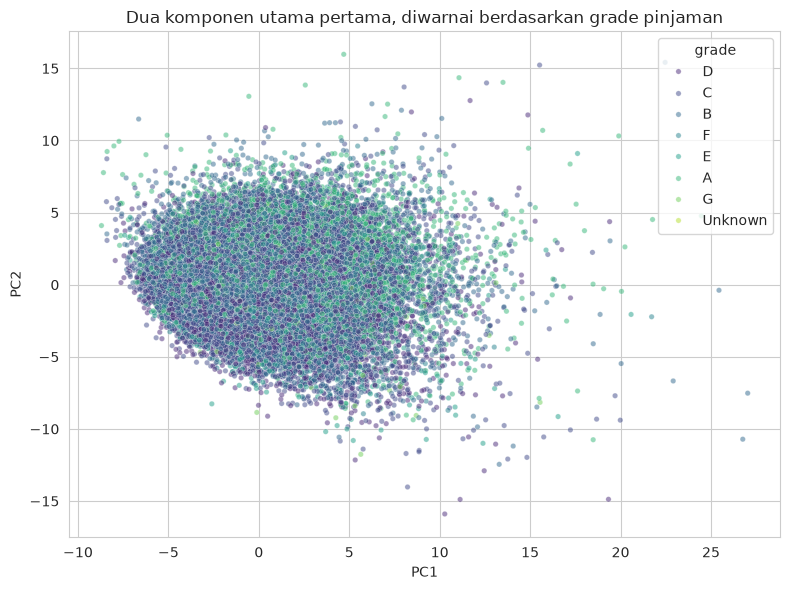

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter_colors = df_integrated['grade'] if 'grade' in df_integrated.columns else None
sns.scatterplot(x=df_pca['PC1'], y=df_pca['PC2'], hue=scatter_colors, palette='viridis',
                 alpha=0.5, s=15, ax=ax, legend='full')
ax.set_title('Dua komponen utama pertama, diwarnai berdasarkan grade pinjaman')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_pca_scatter.png')
plt.show()


## 7. Perbandingan Sebelum vs. Sesudah Preprocessing

Bagian ini merangkum secara kuantitatif dan visual dampak keseluruhan pipeline preprocessing
(cleaning &rarr; integration &rarr; reduction) terhadap dataset, dengan membandingkan tiga kondisi:
data mentah, data setelah cleaning+integrasi, dan data setelah PCA.

In [23]:
comparison = pd.DataFrame({
    'Mentah (before)': {
        'Jumlah baris': df_raw.shape[0],
        'Jumlah kolom': df_raw.shape[1],
        'Rata-rata % missing': round(df_raw.isna().mean().mean() * 100, 2),
        'Kolom 100% kosong': int((df_raw.isna().mean() == 1).sum()),
        'Baris duplikat': int(df_raw.duplicated().sum()),
    },
    'Cleaned + Integrated': {
        'Jumlah baris': df_integrated.shape[0],
        'Jumlah kolom': df_integrated.shape[1],
        'Rata-rata % missing': round(df_integrated.isna().mean().mean() * 100, 2),
        'Kolom 100% kosong': int((df_integrated.isna().mean() == 1).sum()),
        'Baris duplikat': int(df_integrated.duplicated().sum()),
    },
    'Setelah PCA': {
        'Jumlah baris': df_pca.shape[0],
        'Jumlah kolom': df_pca.shape[1],
        'Rata-rata % missing': 0.0,
        'Kolom 100% kosong': 0,
        'Baris duplikat': int(df_pca.duplicated().sum()),
    },
})
comparison


,Mentah (before),Cleaned + Integrated,Setelah PCA
Jumlah baris,59999.0,59999.0,59999.0
Jumlah kolom,151.0,100.0,44.0
Rata-rata % missing,31.8,0.0,0.0
Kolom 100% kosong,1.0,0.0,0.0
Baris duplikat,0.0,0.0,0.0


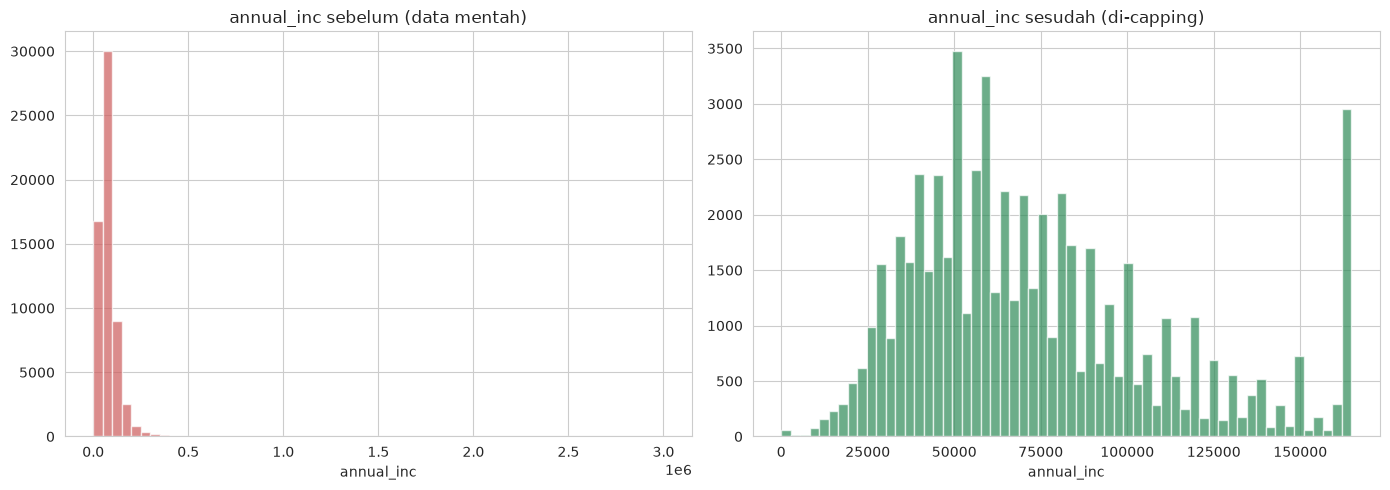

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_raw['annual_inc'].dropna(), bins=60, color='indianred', alpha=0.7)
axes[0].set_title('annual_inc sebelum (data mentah)')
axes[0].set_xlabel('annual_inc')

axes[1].hist(df_integrated['annual_inc'], bins=60, color='seagreen', alpha=0.7)
axes[1].set_title('annual_inc sesudah (di-capping)')
axes[1].set_xlabel('annual_inc')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_before_after_hist.png')
plt.show()


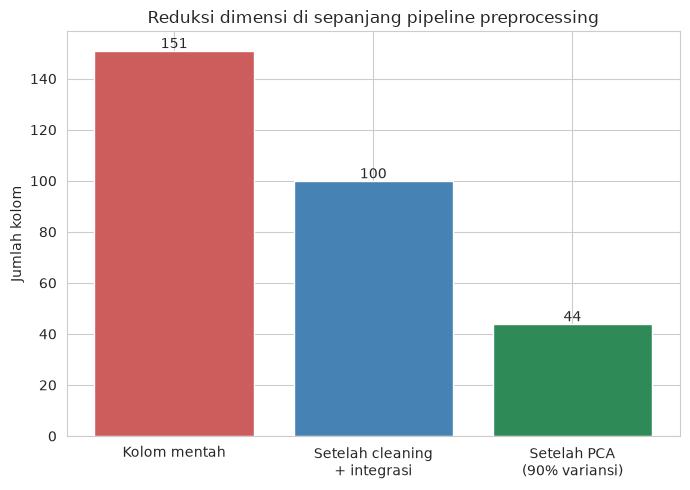

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Kolom mentah', 'Setelah cleaning\n+ integrasi', 'Setelah PCA\n(90% variansi)'],
              [df_raw.shape[1], df_integrated.shape[1], df_pca.shape[1]],
              color=['indianred', 'steelblue', 'seagreen'])
ax.set_ylabel('Jumlah kolom')
ax.set_title('Reduksi dimensi di sepanjang pipeline preprocessing')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, str(int(b.get_height())),
            ha='center')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/09_dimensionality_summary.png')
plt.show()


## 8. Insight Utama & Kesimpulan

Rangkuman temuan penting dari seluruh proses preprocessing di atas:

- Sampel data mentah (60.000 baris &times; 151 kolom, diambil dari 2,26 juta baris data asli)
  benar-benar tidak bersih: terdapat 1 kolom yang 100% kosong dan puluhan kolom lain dengan >95% nilai
  hilang akibat keterbatasan struktural (kolom hanya berlaku untuk subset kecil pinjaman tertentu,
  seperti program hardship, debt settlement, dan aplikasi bersama) kolom-kolom ini dibuang,
  bukan diimputasi.
- Beberapa kolom finansial inti tersimpan sebagai string (`term`, `issue_d`, `emp_length`) dan harus
  diparsing terlebih dahulu sebelum dapat dianalisis secara numerik.
- Outlier pada `annual_inc` dan `dti` bersifat sah (bukan kesalahan input), sehingga ditangani dengan
  IQR capping alih-alih penghapusan baris, menjaga volume data tetap utuh.
- Analisis korelasi berhasil mengidentifikasi belasan pasangan atribut redundan (|r| > 0,9) yang
  berasal dari desain skema LendingClub sendiri (kolom turunan yang secara semantik duplikat);
  sebagian kolom tersebut dibuang tanpa kehilangan informasi.
- PCA berhasil memampatkan puluhan fitur numerik hasil integrasi menjadi jauh lebih sedikit komponen
  utama sambil tetap mempertahankan &ge;90% variansi, mengonfirmasi adanya redundansi moderat yang
  masih tersisa setelah tahap integrasi.
- Secara keseluruhan, pipeline ini berhasil mengubah dataset yang awalnya penuh nilai hilang, tipe
  data campuran, dan outlier tak terkendali, menjadi kumpulan fitur numerik yang bersih, bebas
  redundansi, dan siap dipakai untuk pemodelan lanjutan (misalnya prediksi status pinjaman)
  tanpa kehilangan volume baris maupun informasi statistik utama.

In [26]:
df_integrated.to_csv(f'{PROCESSED_DIR}/lendingclub_cleaned_integrated.csv', index=False)
df_pca.to_csv(f'{PROCESSED_DIR}/lendingclub_pca_components.csv', index=False)
print('Dataset hasil cleaning+integrasi dan komponen PCA berhasil disimpan ke folder data/processed/')


Dataset hasil cleaning+integrasi dan komponen PCA berhasil disimpan ke folder data/processed/
